In [ ]:
# import pandas and CSV files

In [12]:
import pandas as pd

sales = pd.read_csv("sales.csv")
customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")

sales

,order_ID,order_date,sales,profit,customer_id,product_id
0,9091,2010-11-11,605.77,129.33,1,1
1,36355,2009-02-12,129.50,65.49,2,2
2,38887,2009-10-24,378.90,28.46,3,3
3,45860,2012-12-08,69.97,24.25,4,4
4,53156,2012-10-03,186.93,56.44,5,5
...,...,...,...,...,...,...
355,23782,2010-10-01,169.75,-194.85,291,159
356,14662,2011-11-16,5139.88,1275.67,203,301
357,51879,2010-08-24,1382.31,372.26,50,302
358,55846,2009-07-20,221.05,-66.38,184,102


In [ ]:
# Data Cleaning

In [12]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   order_ID     360 non-null    int64  
 1   order_date   360 non-null    str    
 2   sales        360 non-null    float64
 3   profit       360 non-null    float64
 4   customer_id  360 non-null    int64  
 5   product_id   360 non-null    int64  
dtypes: float64(2), int64(3), str(1)
memory usage: 17.0 KB


In [13]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   product_id    302 non-null    int64
 1   product_name  302 non-null    str  
 2   category      301 non-null    str  
dtypes: int64(1), str(2)
memory usage: 7.2 KB


In [14]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customer_id    294 non-null    int64
 1   customer_name  294 non-null    str  
 2   region         294 non-null    str  
dtypes: int64(1), str(2)
memory usage: 7.0 KB


In [13]:
sales.describe().round()

,order_ID,sales,profit,customer_id,product_id
count,360.0,360.0,360.0,360.0,360.0
mean,30549.0,2093.0,329.0,132.0,143.0
std,17082.0,5841.0,1792.0,84.0,88.0
min,293.0,6.0,-2661.0,1.0,1.0
25%,14521.0,151.0,-59.0,56.0,63.0
50%,31459.0,515.0,7.0,128.0,138.0
75%,45411.0,1740.0,232.0,202.0,219.0
max,59651.0,89061.0,27221.0,294.0,303.0


In [17]:
products.describe().round()

,product_id
count,302.0
mean,152.0
std,88.0
min,1.0
25%,76.0
50%,152.0
75%,228.0
max,303.0


In [18]:
customers.describe().round()

,customer_id
count,294.0
mean,148.0
std,85.0
min,1.0
25%,74.0
50%,148.0
75%,221.0
max,294.0


In [ ]:
# Null Values

In [19]:
sales.isnull().sum()

order_ID       0
order_date     0
sales          0
profit         0
customer_id    0
product_id     0
dtype: int64

In [22]:
sales.shape

(360, 6)

In [20]:
products.isnull().sum()

product_id      0
product_name    0
category        1
dtype: int64

In [23]:
products.shape

(302, 3)

In [21]:
customers.isnull().sum()

customer_id      0
customer_name    0
region           0
dtype: int64

In [24]:
customers.shape

(294, 3)

In [ ]:
# Duplicate values

In [29]:
sales[sales.duplicated()].shape

(0, 6)

In [31]:
products[products.duplicated()].shape

(0, 3)

In [32]:
customers[customers.duplicated()].shape

(0, 3)

In [35]:
sales['order_ID'].value_counts().head(10)

order_ID
46624    2
59270    2
46885    2
47872    2
53060    2
43207    2
9091     1
36355    1
38887    1
45860    1
Name: count, dtype: int64

In [65]:
sales[sales['order_ID'] == '45860']

,order_ID,order_date,sales,profit,customer_id,product_id


In [63]:
for col in products.columns:
    if products[col].nunique() < 20:
        print(products[col].value_counts())
        print('-' == 50)

category
Office Supplies    168
Technology          75
Furniture           58
Name: count, dtype: int64
False


In [64]:
for col in customers.columns:
    if customers[col].nunique() < 20:
        print(customers[col].value_counts())
        print('-' == 50)

region
West                     70
Ontario                  63
Prarie                   58
Atlantic                 41
Quebec                   28
Yukon                    17
Northwest Territories    13
Nunavut                   4
Name: count, dtype: int64
False


In [14]:
products.dropna(inplace=True)

In [15]:
products.isnull().sum()

product_id      0
product_name    0
category        0
dtype: int64

In [ ]:
# Merge / Join

In [16]:
df = sales.merge(customers, on="customer_id") \
          .merge(products, on="product_id")

df

,order_ID,order_date,sales,profit,customer_id,product_id,customer_name,region,product_name,category
0,9091,2010-11-11,605.77,129.33,1,1,Adam Hart,Yukon,Nu-Dell Leatherette Frames,Furniture
1,36355,2009-02-12,129.50,65.49,2,2,Anne Pryor,Quebec,"Seth Thomas 8 1/2 Cubicle Clock""""",Furniture
2,38887,2009-10-24,378.90,28.46,3,3,Trudy Bell,West,Acco Recycled 2 Capacity Laser Printer Hanging...,Office Supplies
3,45860,2012-12-08,69.97,24.25,4,4,Matthew Clasen,Prarie,"Wirebound Message Book, 4 per Page",Office Supplies
4,53156,2012-10-03,186.93,56.44,5,5,Bryan Davis,Northwest Territories,Avery 491,Office Supplies
...,...,...,...,...,...,...,...,...,...,...
352,23782,2010-10-01,169.75,-194.85,291,159,Justin MacKendrick,Quebec,Tennsco Commercial Shelving,Office Supplies
353,14662,2011-11-16,5139.88,1275.67,203,301,Karl Brown,Atlantic,M70,Technology
354,51879,2010-08-24,1382.31,372.26,50,302,Monica Federle,Northwest Territories,Howard Miller 11-1/2 Diameter Ridgewood Wall C...,Furniture
355,55846,2009-07-20,221.05,-66.38,184,102,Cari MacIntyre,Ontario,"Wilson Jones Hanging View Binder, White, 1""",Office Supplies


In [ ]:
# Merged Data Cleaning

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 358 entries, 0 to 357
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_ID       358 non-null    int64  
 1   order_date     358 non-null    str    
 2   sales          358 non-null    float64
 3   profit         358 non-null    float64
 4   customer_id    358 non-null    int64  
 5   product_id     358 non-null    int64  
 6   customer_name  358 non-null    str    
 7   region         358 non-null    str    
 8   product_name   358 non-null    str    
 9   category       357 non-null    str    
dtypes: float64(2), int64(3), str(5)
memory usage: 28.1 KB


In [17]:
df.isnull().sum()

order_ID         0
order_date       0
sales            0
profit           0
customer_id      0
product_id       0
customer_name    0
region           0
product_name     0
category         0
dtype: int64

In [74]:
df.shape

(357, 10)

In [18]:
df[df.duplicated()].shape

(0, 10)

In [19]:
df['order_ID'].value_counts().head(10)

order_ID
46624    2
59270    2
46885    2
47872    2
43207    2
9091     1
36355    1
38887    1
45860    1
53156    1
Name: count, dtype: int64

In [20]:
df[df['order_ID'] == '46624']

,order_ID,order_date,sales,profit,customer_id,product_id,customer_name,region,product_name,category


In [ ]:
# Unique Values

In [21]:
df['category'].unique()

<StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str

In [22]:
df['region'].unique()

<StringArray>
[                'Yukon',                'Quebec',                  'West',
                'Prarie', 'Northwest Territories',               'Ontario',
              'Atlantic',               'Nunavut']
Length: 8, dtype: str

In [23]:
for col in df.columns:
    if df[col].nunique() < 20:
        print(df[col].value_counts())
        print('-' == 50)

region
Ontario                  84
West                     77
Prarie                   73
Atlantic                 47
Quebec                   36
Yukon                    23
Northwest Territories    13
Nunavut                   4
Name: count, dtype: int64
False
category
Office Supplies    203
Technology          90
Furniture           64
Name: count, dtype: int64
False


In [ ]:
# Remove null values

In [24]:
df.dropna(inplace=True)

In [10]:
df.isnull().sum()

order_ID         0
order_date       0
sales            0
profit           0
customer_id      0
product_id       0
customer_name    0
region           0
product_name     0
category         0
dtype: int64

In [ ]:
# Format conversion

In [85]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_ID       357 non-null    int64         
 1   order_date     357 non-null    datetime64[us]
 2   sales          357 non-null    float64       
 3   profit         357 non-null    float64       
 4   customer_id    357 non-null    int64         
 5   product_id     357 non-null    int64         
 6   customer_name  357 non-null    str           
 7   region         357 non-null    str           
 8   product_name   357 non-null    str           
 9   category       357 non-null    str           
dtypes: datetime64[us](1), float64(2), int64(3), str(4)
memory usage: 28.0 KB


In [32]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [33]:
df['month'] = df['order_date'].dt.month

In [34]:
df['month']

0      11
1       2
2      10
3      12
4      10
       ..
352    10
353    11
354     8
355     7
356    12
Name: month, Length: 357, dtype: int32

In [35]:
df

,order_ID,order_date,sales,profit,customer_id,product_id,customer_name,region,product_name,category,month
0,9091,2010-11-11,605.77,129.33,1,1,Adam Hart,Yukon,Nu-Dell Leatherette Frames,Furniture,11
1,36355,2009-02-12,129.50,65.49,2,2,Anne Pryor,Quebec,"Seth Thomas 8 1/2 Cubicle Clock""""",Furniture,2
2,38887,2009-10-24,378.90,28.46,3,3,Trudy Bell,West,Acco Recycled 2 Capacity Laser Printer Hanging...,Office Supplies,10
3,45860,2012-12-08,69.97,24.25,4,4,Matthew Clasen,Prarie,"Wirebound Message Book, 4 per Page",Office Supplies,12
4,53156,2012-10-03,186.93,56.44,5,5,Bryan Davis,Northwest Territories,Avery 491,Office Supplies,10
...,...,...,...,...,...,...,...,...,...,...,...
352,23782,2010-10-01,169.75,-194.85,291,159,Justin MacKendrick,Quebec,Tennsco Commercial Shelving,Office Supplies,10
353,14662,2011-11-16,5139.88,1275.67,203,301,Karl Brown,Atlantic,M70,Technology,11
354,51879,2010-08-24,1382.31,372.26,50,302,Monica Federle,Northwest Territories,Howard Miller 11-1/2 Diameter Ridgewood Wall C...,Furniture,8
355,55846,2009-07-20,221.05,-66.38,184,102,Cari MacIntyre,Ontario,"Wilson Jones Hanging View Binder, White, 1""",Office Supplies,7


In [ ]:
# Data Analysis

In [ ]:
# Sales by Region

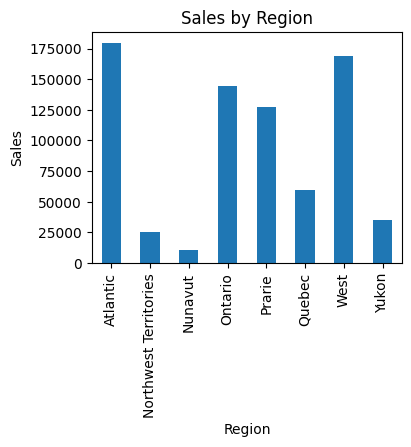

In [40]:
import matplotlib.pyplot as plt
plt.figure(figsize = (4, 3))
df.groupby('region')['sales'].sum().plot(kind='bar')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

In [ ]:
# Profit by Category

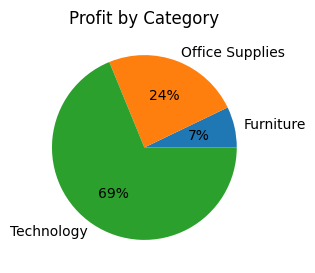

In [66]:
plt.figure(figsize = (4, 3))
profit_category = df.groupby('category')['profit'].sum()
profit_category.plot(kind='pie', autopct = '%0.f%%')
plt.title("Profit by Category")
plt.show()

In [ ]:
# Monthly Sales Trend

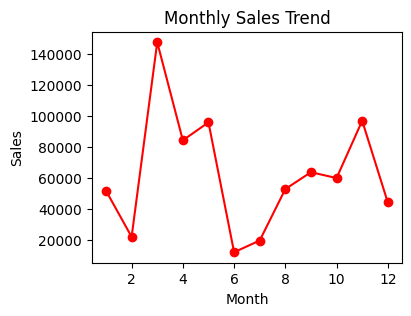

In [67]:
plt.figure(figsize = (4, 3))
monthly_sales = df.groupby('month')['sales'].sum()
monthly_sales.plot(kind='line', color = 'red', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

In [45]:
# Top 4 Products

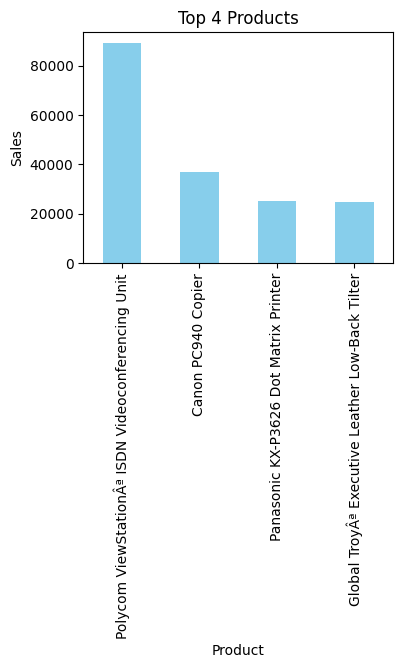

In [68]:
plt.figure(figsize = (4, 3))
top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(4)

top_products.plot(kind='bar', color = 'skyblue')
plt.title("Top 4 Products")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.show()

In [ ]:
# Top 5 Customers

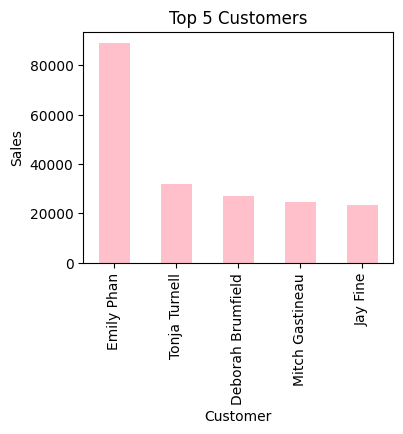

In [69]:
plt.figure(figsize = (4, 3))
top_customers = df.groupby('customer_name')['sales'].sum().sort_values(ascending=False).head(5)

top_customers.plot(kind='bar', color = 'pink')
plt.title("Top 5 Customers")
plt.xlabel("Customer")
plt.ylabel("Sales")
plt.show()